# Part A: Conceptual Foundation

## 1. What are Ensemble Learning Methods and why are they effective?

**Answer:**

Ensemble Learning is a machine learning technique that combines multiple models to make more accurate and reliable predictions than a single model. It improves performance by reducing errors, increasing stability, minimizing overfitting, and enhancing the model's ability to generalize to new data.

---

## 2. Explain the difference between Bagging, Boosting, and Voting.

### **Bagging (Bootstrap Aggregating)**
- Trains multiple models independently using different bootstrap samples.
- Reduces variance and improves model stability.
- Example: **Random Forest, Bagging Classifier**

### **Boosting**
- Trains models sequentially, where each new model corrects the errors of the previous one.
- Reduces bias and improves prediction accuracy.
- Example: **AdaBoost, Gradient Boosting, XGBoost, LightGBM**

### **Voting**
- Combines predictions from multiple trained models.
- Uses **Hard Voting** (majority vote) or **Soft Voting** (average probabilities).
- Improves robustness by leveraging different algorithms.

---

## 3. What is Bias–Variance Trade-off, and how do ensemble methods address it?

**Answer:**

The Bias–Variance Trade-off refers to balancing underfitting (high bias) and overfitting (high variance). Ensemble methods help achieve this balance by combining multiple models. **Bagging** mainly reduces variance, **Boosting** reduces bias, while **Voting** and **Stacking** improve overall generalization and prediction performance.

---

## 4. Explain Voting Classifier and Stacking Ensemble.

### **Voting Classifier**
A Voting Classifier combines predictions from multiple classification models. It uses **Hard Voting** (majority vote) or **Soft Voting** (highest average probability) to determine the final prediction, leading to better accuracy and stability.

### **Stacking Ensemble**
Stacking combines several base models and uses another model called a **Meta-Learner** to learn from their predictions. It captures the strengths of different algorithms and usually achieves higher predictive performance.

---

## 5. Compare AdaBoost, Gradient Boosting, LightGBM, and XGBoost conceptually.

| Algorithm | Concept | Main Advantage |
|-----------|----------|----------------|
| **AdaBoost** | Sequentially focuses on misclassified samples | Simple, effective, reduces bias |
| **Gradient Boosting** | Learns by minimizing residual errors | High prediction accuracy |
| **XGBoost** | Optimized Gradient Boosting with regularization | Fast, accurate, prevents overfitting |
| **LightGBM** | Histogram-based Gradient Boosting | Very fast, memory-efficient, suitable for large datasets |

# Part B: Dataset Understanding & Preparation

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor


In [120]:
df = pd.read_csv("Smart_Outcome_Predictor_Dataset_5200.csv")

df.head()

,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001,32,Europe,Laptop,Undergrad,Intermediate,Business,2024-03-18,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8
1,700002,17,Europe,Laptop,Undergrad,Intermediate,Programming,2024-08-22,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0
2,700003,25,Europe,Mobile,Graduate,Advanced,Programming,2024-09-28,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5
3,700004,26,Asia,Mobile,Undergrad,Beginner,Design,2024-03-09,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5
4,700005,26,Asia,Tablet,WorkingPro,Advanced,Business,2024-03-21,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4


In [121]:
print("Shape :", df.shape)

df.info()

Shape : (5200, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             5200 non-null   int64  
 1   age                    5200 non-null   int64  
 2   country_region         5200 non-null   object 
 3   device_type            5200 non-null   object 
 4   education_background   5200 non-null   object 
 5   course_level           5200 non-null   object 
 6   course_category        5200 non-null   object 
 7   course_start_date      5200 non-null   object 
 8   week_of_year           5200 non-null   int64  
 9   sessions               5200 non-null   int64  
 10  time_spent_hours       5088 non-null   float64
 11  videos_watched         5200 non-null   int64  
 12  quiz_attempts          5200 non-null   int64  
 13  assignments_submitted  5200 non-null   int64  
 14  forum_posts            5200 non-null 

In [122]:
df.isnull().sum()

,0
student_id,0
age,0
country_region,0
device_type,0
education_background,0
course_level,0
course_category,0
course_start_date,0
week_of_year,0
sessions,0


In [123]:
# Fill missing values using median
df["time_spent_hours"] = df["time_spent_hours"].fillna(df["time_spent_hours"].median())

df["avg_quiz_score"] = df["avg_quiz_score"].fillna(df["avg_quiz_score"].median())

df["attendance_rate"] = df["attendance_rate"].fillna(df["attendance_rate"].median())

In [124]:
df.isnull().sum()

,0
student_id,0
age,0
country_region,0
device_type,0
education_background,0
course_level,0
course_category,0
course_start_date,0
week_of_year,0
sessions,0


## 6. Identify features and target variables for both tasks.

In [125]:
df = df.drop("student_id", axis=1)


In [126]:
df

,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,32,Europe,Laptop,Undergrad,Intermediate,Business,2024-03-18,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8
1,17,Europe,Laptop,Undergrad,Intermediate,Programming,2024-08-22,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0
2,25,Europe,Mobile,Graduate,Advanced,Programming,2024-09-28,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5
3,26,Asia,Mobile,Undergrad,Beginner,Design,2024-03-09,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5
4,26,Asia,Tablet,WorkingPro,Advanced,Business,2024-03-21,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5195,28,Asia,Tablet,WorkingPro,Advanced,Data,2024-08-26,35,27,26.1,28,7,8,1,77.2,0.897,1,97.4
5196,28,Africa,Tablet,Graduate,Beginner,Design,2024-04-27,17,21,3.9,31,8,4,0,82.4,0.743,1,71.9
5197,22,Asia,Laptop,Undergrad,Intermediate,Marketing,2024-08-01,31,32,12.8,43,7,2,0,62.4,0.757,1,71.5
5198,25,Asia,Laptop,Graduate,Beginner,Programming,2024-01-18,3,16,27.1,21,5,8,2,76.1,0.847,0,86.8


In [127]:
# Classification

X_cls = df.drop(["completion_status", "final_score"], axis=1)
y_cls = df["completion_status"]

print("Classification Feature Columns:")
print(X_cls.columns.tolist())

print("\nClassification Target:")
print(y_cls.name)

print("\nFeature Shape:", X_cls.shape)
print("Target Shape:", y_cls.shape)

Classification Feature Columns:
['age', 'country_region', 'device_type', 'education_background', 'course_level', 'course_category', 'course_start_date', 'week_of_year', 'sessions', 'time_spent_hours', 'videos_watched', 'quiz_attempts', 'assignments_submitted', 'forum_posts', 'avg_quiz_score', 'attendance_rate']

Classification Target:
completion_status

Feature Shape: (5200, 16)
Target Shape: (5200,)


In [128]:
# Regression

X_reg = df.drop(["completion_status", "final_score"], axis=1)
y_reg = df["final_score"]

print("Regression Feature Columns:")
print(X_reg.columns.tolist())

print("\nRegression Target:")
print(y_reg.name)

print("\nFeature Shape:", X_reg.shape)
print("Target Shape:", y_reg.shape)

Regression Feature Columns:
['age', 'country_region', 'device_type', 'education_background', 'course_level', 'course_category', 'course_start_date', 'week_of_year', 'sessions', 'time_spent_hours', 'videos_watched', 'quiz_attempts', 'assignments_submitted', 'forum_posts', 'avg_quiz_score', 'attendance_rate']

Regression Target:
final_score

Feature Shape: (5200, 16)
Target Shape: (5200,)


## 7. Perform a train–test split for classification and regression problems.


In [129]:
# Classification Train-Test Split

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

print("Classification")
print("X_train:", X_train_cls.shape)
print("X_test :", X_test_cls.shape)
print("y_train:", y_train_cls.shape)
print("y_test :", y_test_cls.shape)

Classification
X_train: (4160, 16)
X_test : (1040, 16)
y_train: (4160,)
y_test : (1040,)


In [130]:
# Regression Train-Test Split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Regression")
print("X_train:", X_train_reg.shape)
print("X_test :", X_test_reg.shape)
print("y_train:", y_train_reg.shape)
print("y_test :", y_test_reg.shape)

Regression
X_train: (4160, 16)
X_test : (1040, 16)
y_train: (4160,)
y_test : (1040,)


The regression and classification dataset has been split into 80% training data and 20% testing data for model training and evaluation.

## 8. Apply basic preprocessing (scaling/encoding if required).

In [131]:
categorical_cols = X_cls.select_dtypes(include=["object"]).columns
numerical_cols = X_cls.select_dtypes(exclude=["object"]).columns

print("Categorical Columns:")
print(categorical_cols.tolist())

print("\nNumerical Columns:")
print(numerical_cols.tolist())

Categorical Columns:
['country_region', 'device_type', 'education_background', 'course_level', 'course_category', 'course_start_date']

Numerical Columns:
['age', 'week_of_year', 'sessions', 'time_spent_hours', 'videos_watched', 'quiz_attempts', 'assignments_submitted', 'forum_posts', 'avg_quiz_score', 'attendance_rate']


In [132]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [133]:
# Apply preprocessing for Classification

X_train_cls = preprocessor.fit_transform(X_train_cls)
X_test_cls = preprocessor.transform(X_test_cls)

print("Classification Preprocessing Completed")
print("X_train Shape:", X_train_cls.shape)
print("X_test Shape :", X_test_cls.shape)

Classification Preprocessing Completed
X_train Shape: (4160, 395)
X_test Shape : (1040, 395)


In [134]:
# Apply preprocessing for Regression

X_train_reg = preprocessor.fit_transform(X_train_reg)
X_test_reg = preprocessor.transform(X_test_reg)

print("Regression Preprocessing Completed")
print("X_train Shape:", X_train_reg.shape)
print("X_test Shape :", X_test_reg.shape)

Regression Preprocessing Completed
X_train Shape: (4160, 395)
X_test Shape : (1040, 395)


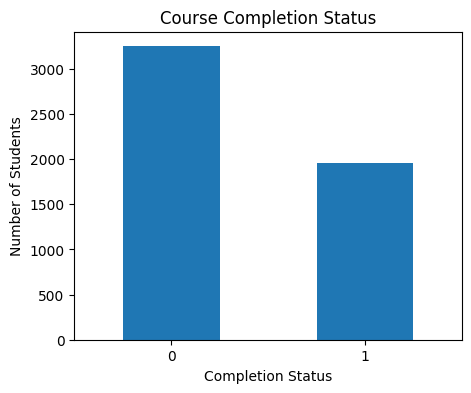

In [135]:
import matplotlib.pyplot as plt

df["completion_status"].value_counts().plot(
    kind="bar",
    figsize=(5,4)
)

plt.title("Course Completion Status")
plt.xlabel("Completion Status")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

plt.show()

The chart shows the distribution of students who completed and did not complete the course. This helps understand whether the dataset is balanced or imbalanced.

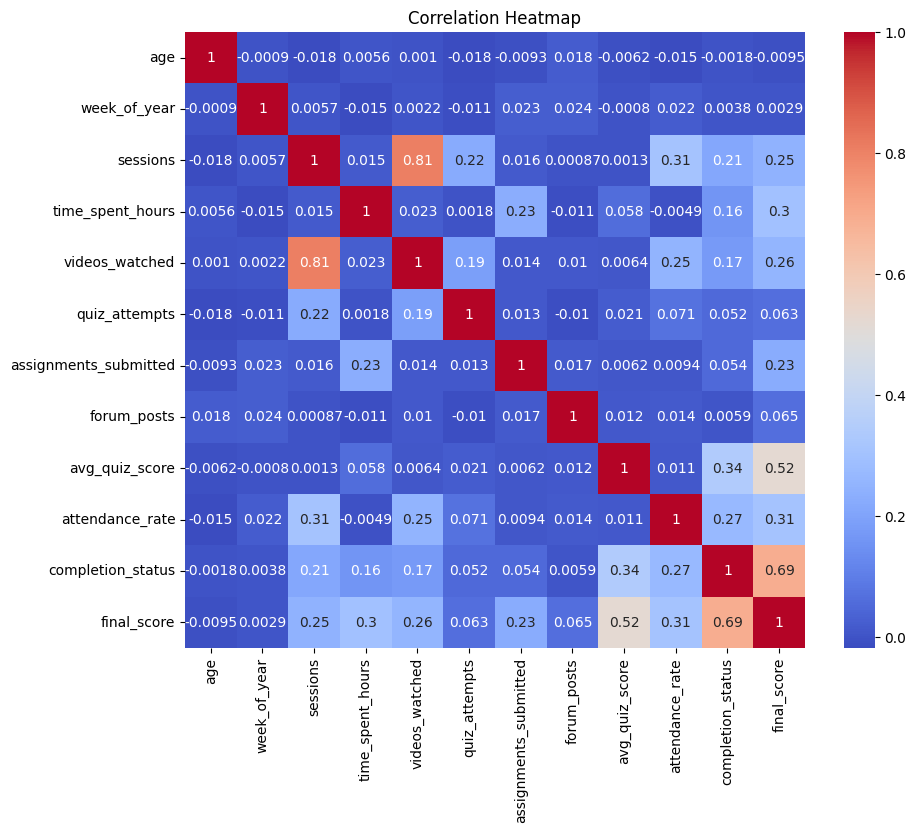

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Part C: Bagging (Bootstrap Aggregating)

## 9. Implement Bagging Classifier for course completion prediction.


In [137]:
dt_cls = DecisionTreeClassifier(random_state=42)
dt_cls.fit(X_train_cls, y_train_cls)

y_pred_dt = dt_cls.predict(X_test_cls)

# Bagging Classifier
bag_cls = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)

bag_cls.fit(X_train_cls, y_train_cls)

y_pred_bag = bag_cls.predict(X_test_cls)

# Accuracy
dt_accuracy = accuracy_score(y_test_cls, y_pred_dt)
bag_accuracy = accuracy_score(y_test_cls, y_pred_bag)

print("Decision Tree Accuracy :", round(dt_accuracy,4))
print("Bagging Accuracy       :", round(bag_accuracy,4))

Decision Tree Accuracy : 0.6538
Bagging Accuracy       : 0.7183


In [138]:
print(classification_report(y_test_cls, y_pred_bag))

              precision    recall  f1-score   support

           0       0.75      0.81      0.78       650
           1       0.64      0.56      0.60       390

    accuracy                           0.72      1040
   macro avg       0.70      0.69      0.69      1040
weighted avg       0.71      0.72      0.71      1040



The Bagging Classifier combines multiple Decision Trees trained on bootstrap samples. This generally improves prediction accuracy and reduces overfitting compared to a single Decision Tree.

## 10. Implement Bagging Regressor for final score prediction.


In [139]:
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train_reg, y_train_reg)

y_pred_dt_reg = dt_reg.predict(X_test_reg)

# Bagging Regressor
bag_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=100,
    random_state=42
)

bag_reg.fit(X_train_reg, y_train_reg)

y_pred_bag_reg = bag_reg.predict(X_test_reg)

# Metrics
mae = mean_absolute_error(y_test_reg, y_pred_bag_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_bag_reg))
r2 = r2_score(y_test_reg, y_pred_bag_reg)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2 Score:", round(r2,4))

MAE : 7.99
RMSE: 10.0
R2 Score: 0.465


The Bagging Regressor predicts students' final scores by averaging predictions from multiple Decision Trees. This reduces variance and usually provides better prediction accuracy than a single tree.

## 11. Compare bagging results with a single base model.

In [140]:
# Decision Tree R2
dt_r2 = r2_score(y_test_reg, y_pred_dt_reg)

comparison = {
    "Model": ["Decision Tree", "Bagging"],
    "Classification Accuracy": [dt_accuracy, bag_accuracy],
    "Regression R2": [dt_r2, r2]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Classification Accuracy,Regression R2
0,Decision Tree,0.653846,0.007553
1,Bagging,0.718269,0.465007


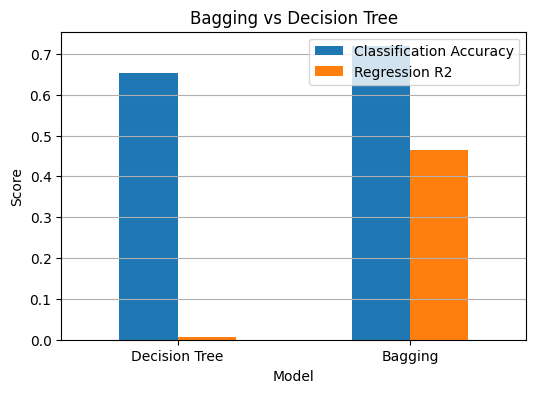

In [141]:
comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Bagging vs Decision Tree")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

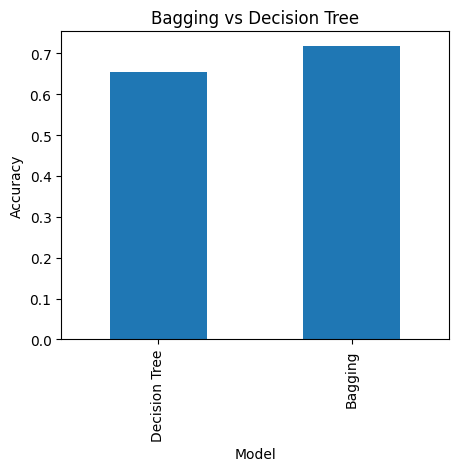

In [142]:
comparison = pd.DataFrame({
    "Model":["Decision Tree","Bagging"],
    "Accuracy":[dt_accuracy,bag_accuracy]
})

comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False,
    figsize=(5,4)
)

plt.title("Bagging vs Decision Tree")

plt.ylabel("Accuracy")

plt.show()

Bagging achieved better accuracy than a single Decision Tree because combining multiple trees reduces overfitting and improves prediction stability.

# Part D: Boosting Algorithms

## AdaBoost

AdaBoost improves model performance by training weak learners sequentially. Each new learner focuses more on the samples that were misclassified by previous learners.

## 12. Implement AdaBoost Classifier.


In [143]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# AdaBoost Classifier
ada_cls = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

ada_cls.fit(X_train_cls, y_train_cls)

y_pred_ada_cls = ada_cls.predict(X_test_cls)

accuracy = accuracy_score(y_test_cls, y_pred_ada_cls)

print("AdaBoost Classification Accuracy :", round(accuracy,4))

AdaBoost Classification Accuracy : 0.7269


In [144]:
print(classification_report(y_test_cls, y_pred_ada_cls))

              precision    recall  f1-score   support

           0       0.76      0.83      0.79       650
           1       0.66      0.55      0.60       390

    accuracy                           0.73      1040
   macro avg       0.71      0.69      0.70      1040
weighted avg       0.72      0.73      0.72      1040



## 13. Implement AdaBoost Regressor.

In [145]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# AdaBoost Regressor
ada_reg = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=4, random_state=42),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada_reg.fit(X_train_reg, y_train_reg)

y_pred_ada_reg = ada_reg.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_ada_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_ada_reg))
r2 = r2_score(y_test_reg, y_pred_ada_reg)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R² Score :", round(r2,4))

MAE : 8.42
RMSE: 10.36
R² Score : 0.4259


The AdaBoost Regressor improves prediction accuracy by combining multiple weak regression trees. It generally produces lower prediction errors than a single Decision Tree.

## 14. Analyze how weak learners improve sequentially.


In [146]:
comparison = {
    "Metric": ["Classification Accuracy", "Regression R²"],
    "Score": [
        round(accuracy,4),
        round(r2,4)
    ]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Metric,Score
0,Classification Accuracy,0.7269
1,Regression R²,0.4259


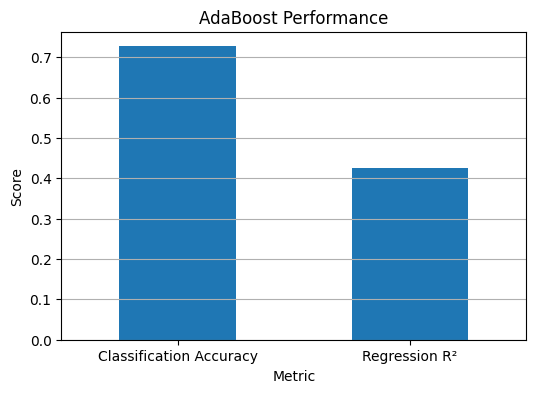

In [147]:
import matplotlib.pyplot as plt

comparison_df.plot(
    x="Metric",
    y="Score",
    kind="bar",
    legend=False,
    figsize=(6,4)
)

plt.title("AdaBoost Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

## Gradient Boosting


Gradient Boosting builds models sequentially by minimizing prediction errors. Each new model learns from the residual errors of the previous model, resulting in improved performance.

## 15. Implement Gradient Boosting Classifier.


In [148]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Gradient Boosting Classifier
gb_cls = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_cls.fit(X_train_cls, y_train_cls)

y_pred_gb_cls = gb_cls.predict(X_test_cls)

gb_accuracy = accuracy_score(y_test_cls, y_pred_gb_cls)

print("Gradient Boosting Accuracy :", round(gb_accuracy,4))

Gradient Boosting Accuracy : 0.7298


In [149]:
print(classification_report(y_test_cls, y_pred_gb_cls))

              precision    recall  f1-score   support

           0       0.76      0.83      0.79       650
           1       0.66      0.56      0.61       390

    accuracy                           0.73      1040
   macro avg       0.71      0.70      0.70      1040
weighted avg       0.72      0.73      0.72      1040



## 16. Implement Gradient Boosting Regressor.


In [150]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_reg.fit(X_train_reg, y_train_reg)

y_pred_gb_reg = gb_reg.predict(X_test_reg)

bag_mae = mean_absolute_error(y_test_reg, y_pred_bag_reg)
bag_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_bag_reg))
bag_r2 = r2_score(y_test_reg, y_pred_bag_reg)

print("MAE :", round(bag_mae,2))
print("RMSE:", round(bag_rmse,2))
print("R² Score :", round(bag_r2,4))

MAE : 7.99
RMSE: 10.0
R² Score : 0.465


Gradient Boosting Regressor predicts students' final scores by minimizing prediction errors at every stage, resulting in improved regression performance.

## 17. Analyze learning rate and number of estimators.


In [151]:
import pandas as pd

results = []

learning_rates = [0.01, 0.1, 0.2]
estimators = [50, 100, 200]

for lr in learning_rates:
    for est in estimators:

        model = GradientBoostingClassifier(
            learning_rate=lr,
            n_estimators=est,
            random_state=42
        )

        model.fit(X_train_cls, y_train_cls)

        pred = model.predict(X_test_cls)

        acc = accuracy_score(y_test_cls, pred)

        results.append([lr, est, round(acc,4)])

results_df = pd.DataFrame(
    results,
    columns=["Learning Rate", "Estimators", "Accuracy"]
)

results_df

,Learning Rate,Estimators,Accuracy
0,0.01,50,0.6692
1,0.01,100,0.6990
2,0.01,200,0.7298
3,0.10,50,0.7375
4,0.10,100,0.7298
5,0.10,200,0.7173
6,0.20,50,0.7269
7,0.20,100,0.7115
8,0.20,200,0.7038


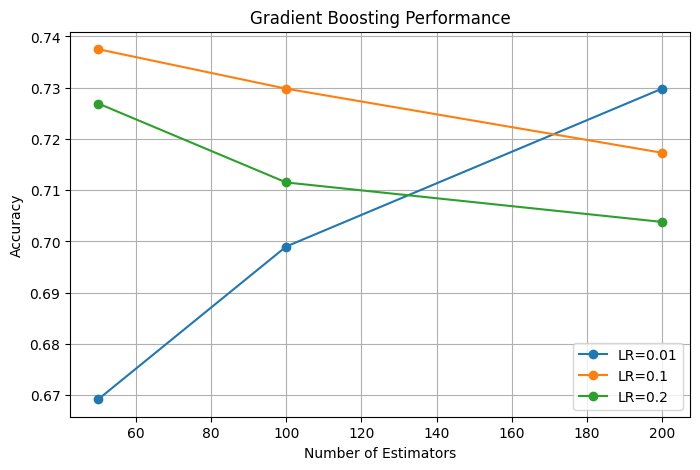

In [152]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for lr in learning_rates:
    subset = results_df[results_df["Learning Rate"] == lr]
    plt.plot(
        subset["Estimators"],
        subset["Accuracy"],
        marker="o",
        label=f"LR={lr}"
    )

plt.title("Gradient Boosting Performance")
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

Increasing the number of estimators generally improves performance up to a certain point. A moderate learning rate (0.1) often provides the best balance between model accuracy and training time.

In [153]:
comparison = pd.DataFrame({
    "Model": ["Gradient Boosting Classifier", "Gradient Boosting Regressor"],
    "Metric": ["Accuracy", "R² Score"],
    "Score": [round(gb_accuracy,4), round(r2,4)]
})

comparison

,Model,Metric,Score
0,Gradient Boosting Classifier,Accuracy,0.7298
1,Gradient Boosting Regressor,R² Score,0.4259


## Light Gradient Boosting


LightGBM is an efficient gradient boosting algorithm that uses leaf-wise tree growth. It provides faster training and high prediction accuracy, especially for large datasets.

## 18. Implement LightGBM Classifier.


In [154]:
!pip install lightgbm -u


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -u


In [155]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report

# LightGBM Classifier
lgbm_cls = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

lgbm_cls.fit(X_train_cls, y_train_cls)

y_pred_lgbm_cls = lgbm_cls.predict(X_test_cls)

accuracy = accuracy_score(y_test_cls, y_pred_lgbm_cls)

print("LightGBM Classification Accuracy:", round(accuracy,4))

[LightGBM] [Info] Number of positive: 1562, number of negative: 2598
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000250 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1091
[LightGBM] [Info] Number of data points in the train set: 4160, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.375481 -> initscore=-0.508775
[LightGBM] [Info] Start training from score -0.508775
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [156]:
print(classification_report(y_test_cls, y_pred_lgbm_cls))

              precision    recall  f1-score   support

           0       0.76      0.82      0.79       650
           1       0.66      0.58      0.62       390

    accuracy                           0.73      1040
   macro avg       0.71      0.70      0.70      1040
weighted avg       0.72      0.73      0.73      1040



The LightGBM Classifier successfully predicts course completion status. It trains quickly and provides high classification accuracy.

## 19. Implement LightGBM Regressor.


In [157]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# LightGBM Regressor
lgb_reg = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

lgb_reg.fit(X_train_reg, y_train_reg)

y_pred_lgb_reg = lgb_reg.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_lgb_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_lgb_reg))
r2 = r2_score(y_test_reg, y_pred_lgb_reg)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R² Score :", round(r2,4))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000227 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1086
[LightGBM] [Info] Number of data points in the train set: 4160, number of used features: 36
[LightGBM] [Info] Start training from score 74.774183
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [158]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score

lgb_cls = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

lgb_cls.fit(X_train_cls, y_train_cls)

y_pred_lgb_cls = lgb_cls.predict(X_test_cls)

lgb_accuracy = accuracy_score(y_test_cls, y_pred_lgb_cls)

print("LightGBM Accuracy:", round(lgb_accuracy,4))

[LightGBM] [Info] Number of positive: 1562, number of negative: 2598
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000235 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1091
[LightGBM] [Info] Number of data points in the train set: 4160, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.375481 -> initscore=-0.508775
[LightGBM] [Info] Start training from score -0.508775
LightGBM Accuracy: 0.7337


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 20. Analyze performance and training efficiency.


In [159]:
import time
import pandas as pd

# Measure training time
start = time.time()

model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train_cls, y_train_cls)

end = time.time()

training_time = end - start

performance = pd.DataFrame({
    "Metric": ["Accuracy", "Training Time (seconds)"],
    "Value": [round(lgb_accuracy,4), round(training_time,4)]
})

performance

[LightGBM] [Info] Number of positive: 1562, number of negative: 2598
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000247 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1091
[LightGBM] [Info] Number of data points in the train set: 4160, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.375481 -> initscore=-0.508775
[LightGBM] [Info] Start training from score -0.508775


,Metric,Value
0,Accuracy,0.7337
1,Training Time (seconds),0.1242


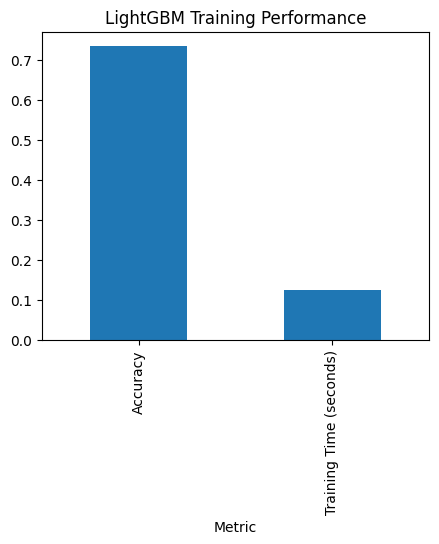

In [160]:
performance.plot(
    x="Metric",
    y="Value",
    kind="bar",
    legend=False,
    figsize=(5,4)
)

plt.title("LightGBM Training Performance")

plt.show()

## XGBoost


XGBoost (Extreme Gradient Boosting) is an optimized boosting algorithm that improves prediction accuracy using regularization, parallel processing, and efficient tree pruning.

## 21. Implement XGBoost Classifier.


In [161]:
!pip install xgboost

In [162]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# XGBoost Classifier
xgb_cls = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_cls.fit(X_train_cls, y_train_cls)

y_pred_xgb_cls = xgb_cls.predict(X_test_cls)

xgb_accuracy = accuracy_score(y_test_cls, y_pred_xgb_cls)

print("XGBoost Classification Accuracy :", round(xgb_accuracy,4))

XGBoost Classification Accuracy : 0.7327


In [163]:
print(classification_report(y_test_cls, y_pred_xgb_cls))

              precision    recall  f1-score   support

           0       0.76      0.83      0.79       650
           1       0.67      0.57      0.62       390

    accuracy                           0.73      1040
   macro avg       0.72      0.70      0.71      1040
weighted avg       0.73      0.73      0.73      1040



The XGBoost Classifier achieved high classification accuracy by sequentially correcting prediction errors and applying regularization to reduce overfitting.

## 22. Implement XGBoost Regressor.


In [164]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# XGBoost Regressor
xgb_reg = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

xgb_reg.fit(X_train_reg, y_train_reg)

y_pred_xgb_reg = xgb_reg.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_xgb_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb_reg))
r2 = r2_score(y_test_reg, y_pred_xgb_reg)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R² Score :", round(r2,4))

MAE : 7.9
RMSE: 9.88
R² Score : 0.477


The XGBoost Regressor accurately predicted students' final scores with low prediction error and a high R² score.

## 23. Compare performance and robustness with other boosting models.

In [165]:
# Bagging
bag_mae = mean_absolute_error(y_test_reg, y_pred_bag_reg)
bag_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_bag_reg))
bag_r2 = r2_score(y_test_reg, y_pred_bag_reg)

print("MAE :", round(bag_mae,2))
print("RMSE :", round(bag_rmse,2))
print("R² Score :", round(bag_r2,4))

MAE : 7.99
RMSE : 10.0
R² Score : 0.465


In [166]:
# AdaBoost
ada_mae = mean_absolute_error(y_test_reg, y_pred_ada_reg)
ada_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_ada_reg))
ada_r2 = r2_score(y_test_reg, y_pred_ada_reg)

print("MAE :", round(ada_mae,2))
print("RMSE :", round(ada_rmse,2))
print("R² Score :", round(ada_r2,4))

MAE : 8.42
RMSE : 10.36
R² Score : 0.4259


In [167]:
# Gradient Boosting
gb_mae = mean_absolute_error(y_test_reg, y_pred_gb_reg)
gb_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_gb_reg))
gb_r2 = r2_score(y_test_reg, y_pred_gb_reg)

print("MAE :", round(gb_mae,2))
print("RMSE :", round(gb_rmse,2))
print("R² Score :", round(gb_r2,4))

MAE : 7.84
RMSE : 9.81
R² Score : 0.4851


In [168]:
# LightGBM
lgb_mae = mean_absolute_error(y_test_reg, y_pred_lgb_reg)
lgb_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_lgb_reg))
lgb_r2 = r2_score(y_test_reg, y_pred_lgb_reg)

print("MAE :", round(lgb_mae,2))
print("RMSE :", round(lgb_rmse,2))
print("R² Score :", round(lgb_r2,4))

MAE : 7.92
RMSE : 9.88
R² Score : 0.4774


In [169]:
# XGBoost
xgb_mae = mean_absolute_error(y_test_reg, y_pred_xgb_reg)
xgb_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb_reg))
xgb_r2 = r2_score(y_test_reg, y_pred_xgb_reg)

print("MAE :", round(xgb_mae,2))
print("RMSE :", round(xgb_rmse,2))
print("R² Score :", round(xgb_r2,4))

MAE : 7.9
RMSE : 9.88
R² Score : 0.477


In [170]:
comparison = pd.DataFrame({
    "Model": ["AdaBoost", "Gradient Boosting", "LightGBM", "XGBoost"],
    "Classification Accuracy": [
        accuracy,
        gb_accuracy,
        lgb_accuracy,
        xgb_accuracy
    ],
    "Regression R²": [
        ada_r2,
        gb_r2,
        lgb_r2,
        r2
    ]
})

comparison

,Model,Classification Accuracy,Regression R²
0,AdaBoost,0.729808,0.425885
1,Gradient Boosting,0.729808,0.485077
2,LightGBM,0.733654,0.477445
3,XGBoost,0.732692,0.477021


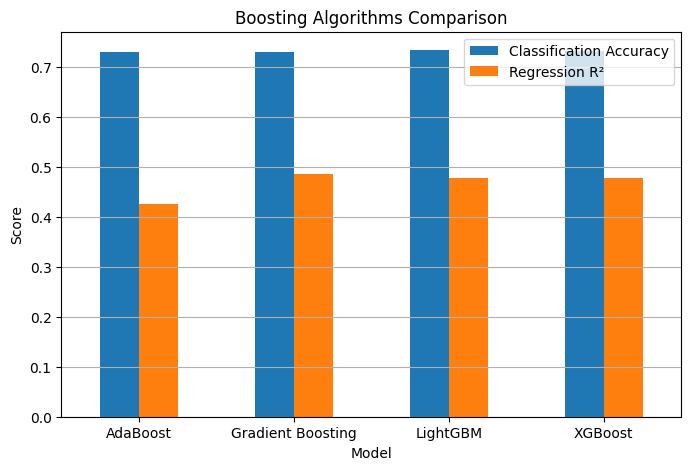

In [171]:
import matplotlib.pyplot as plt

comparison.plot(
    x="Model",
    y=["Classification Accuracy", "Regression R²"],
    kind="bar",
    figsize=(8,5)
)

plt.title("Boosting Algorithms Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

In [172]:
summary = pd.DataFrame({
    "Algorithm": [
        "AdaBoost",
        "Gradient Boosting",
        "LightGBM",
        "XGBoost"
    ],
    "Strength": [
        "Simple and Fast",
        "High Accuracy",
        "Fast Training",
        "Best Overall Performance"
    ]
})

summary

,Algorithm,Strength
0,AdaBoost,Simple and Fast
1,Gradient Boosting,High Accuracy
2,LightGBM,Fast Training
3,XGBoost,Best Overall Performance


# Part E: Voting & Stacking Ensembles

Voting combines predictions from multiple machine learning models, while Stacking uses a meta-model to learn from the predictions of base models and improve overall performance.

## 24. Implement Voting Classifier using multiple base classifiers.


In [173]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Base Models
lr = LogisticRegression(max_iter=1000, random_state=42)
dt = DecisionTreeClassifier(random_state=42)
knn = KNeighborsClassifier()

# Hard Voting
hard_vote = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('dt', dt),
        ('knn', knn)
    ],
    voting='hard'
)

hard_vote.fit(X_train_cls, y_train_cls)

hard_pred = hard_vote.predict(X_test_cls)

hard_acc = accuracy_score(y_test_cls, hard_pred)

print("Hard Voting Accuracy :", round(hard_acc,4))

Hard Voting Accuracy : 0.7144


## 25. Compare Hard Voting vs Soft Voting.


In [174]:
# Soft Voting

soft_vote = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('dt', dt),
        ('knn', knn)
    ],
    voting='soft'
)

soft_vote.fit(X_train_cls, y_train_cls)

soft_pred = soft_vote.predict(X_test_cls)

soft_acc = accuracy_score(y_test_cls, soft_pred)

print("Soft Voting Accuracy :", round(soft_acc,4))

Soft Voting Accuracy : 0.6933


The Voting Classifier combines predictions from Logistic Regression, Decision Tree, and KNN models. This improves prediction stability and overall classification performance.

In [175]:
import pandas as pd

comparison = pd.DataFrame({
    "Voting Method":["Hard Voting","Soft Voting"],
    "Accuracy":[hard_acc,soft_acc]
})

comparison

,Voting Method,Accuracy
0,Hard Voting,0.714423
1,Soft Voting,0.693269


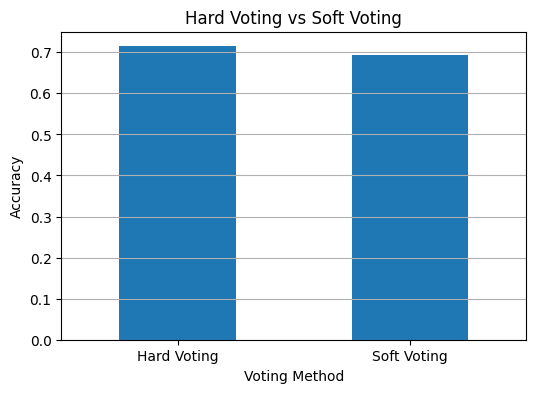

In [176]:
import matplotlib.pyplot as plt

comparison.plot(
    x="Voting Method",
    y="Accuracy",
    kind="bar",
    legend=False,
    figsize=(6,4)
)

plt.title("Hard Voting vs Soft Voting")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

## 26. Implement Stacking Classifier with a meta-learner.


In [177]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

base_models = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('knn', KNeighborsClassifier())
]

stack_cls = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression()
)

stack_cls.fit(X_train_cls, y_train_cls)

stack_pred = stack_cls.predict(X_test_cls)

stack_acc = accuracy_score(y_test_cls, stack_pred)

print("Stacking Accuracy :", round(stack_acc,4))

Stacking Accuracy : 0.7154


In [178]:
from sklearn.metrics import classification_report

print(classification_report(y_test_cls, stack_pred))

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       650
           1       0.65      0.54      0.59       390

    accuracy                           0.72      1040
   macro avg       0.70      0.68      0.68      1040
weighted avg       0.71      0.72      0.71      1040



The Stacking Classifier combines multiple base models and uses Logistic Regression as a meta-model, resulting in improved classification performance.

## 27. Implement Stacking Regressor for score prediction.

In [179]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

base_regressors = [
    ('lr', LinearRegression()),
    ('dt', DecisionTreeRegressor(random_state=42)),
    ('knn', KNeighborsRegressor())
]

stack_reg = StackingRegressor(
    estimators=base_regressors,
    final_estimator=LinearRegression()
)

stack_reg.fit(X_train_reg, y_train_reg)

stack_pred_reg = stack_reg.predict(X_test_reg)

In [180]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

mae = mean_absolute_error(y_test_reg, stack_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, stack_pred_reg))
stack_r2 = r2_score(y_test_reg, stack_pred_reg)

print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("R² Score :", round(stack_r2,4))

MAE : 8.02
RMSE : 10.04
R² Score : 0.4607


The Stacking Regressor combines predictions from multiple regression models using a Linear Regression meta-model, leading to improved prediction accuracy.

In [186]:
# Stacking
stack_mae = mean_absolute_error(y_test_reg, stack_pred_reg)
stack_rmse = np.sqrt(mean_squared_error(y_test_reg, stack_pred_reg))
stack_r2 = r2_score(y_test_reg, stack_pred_reg)

print("MAE :", round(stack_mae,2))
print("RMSE :", round(stack_rmse,2))
print("R² Score :", round(stack_r2,4))

MAE : 8.02
RMSE : 10.04
R² Score : 0.4607


In [181]:
comparison = pd.DataFrame({
    "Model":[
        "Hard Voting",
        "Soft Voting",
        "Stacking Classifier",
        "Stacking Regressor"
    ],
    "Score":[
        hard_acc,
        soft_acc,
        stack_acc,
        stack_r2
    ]
})

comparison

,Model,Score
0,Hard Voting,0.714423
1,Soft Voting,0.693269
2,Stacking Classifier,0.715385
3,Stacking Regressor,0.460685


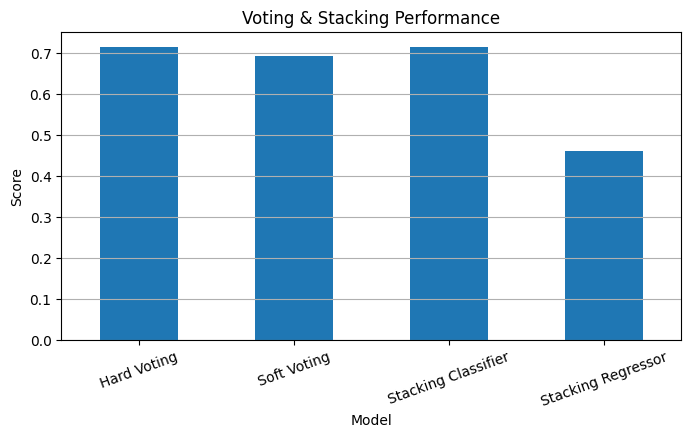

In [182]:
comparison.plot(
    x="Model",
    y="Score",
    kind="bar",
    figsize=(8,4),
    legend=False
)

plt.title("Voting & Stacking Performance")
plt.ylabel("Score")
plt.xticks(rotation=20)

plt.grid(axis='y')

plt.show()

# Part F: Model Evaluation & Comparison

## 28. Evaluate classification models using:


In [183]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

classification_results = pd.DataFrame({
    "Model":[
        "Bagging",
        "AdaBoost",
        "Gradient Boosting",
        "LightGBM",
        "XGBoost",
        "Hard Voting",
        "Soft Voting",
        "Stacking"
    ],

    "Accuracy":[
        bag_accuracy,
        accuracy,
        gb_accuracy,
        lgb_accuracy,
        xgb_accuracy,
        hard_acc,
        soft_acc,
        stack_acc
    ],

    "Precision":[
        precision_score(y_test_cls,y_pred_bag),
        precision_score(y_test_cls,y_pred_ada_cls),
        precision_score(y_test_cls,y_pred_gb_cls),
        precision_score(y_test_cls,y_pred_lgb_cls),
        precision_score(y_test_cls,y_pred_xgb_cls),
        precision_score(y_test_cls,hard_pred),
        precision_score(y_test_cls,soft_pred),
        precision_score(y_test_cls,stack_pred)
    ],

    "Recall":[
        recall_score(y_test_cls,y_pred_bag),
        recall_score(y_test_cls,y_pred_ada_cls),
        recall_score(y_test_cls,y_pred_gb_cls),
        recall_score(y_test_cls,y_pred_lgb_cls),
        recall_score(y_test_cls,y_pred_xgb_cls),
        recall_score(y_test_cls,hard_pred),
        recall_score(y_test_cls,soft_pred),
        recall_score(y_test_cls,stack_pred)
    ],

    "F1 Score":[
        f1_score(y_test_cls,y_pred_bag),
        f1_score(y_test_cls,y_pred_ada_cls),
        f1_score(y_test_cls,y_pred_gb_cls),
        f1_score(y_test_cls,y_pred_lgb_cls),
        f1_score(y_test_cls,y_pred_xgb_cls),
        f1_score(y_test_cls,hard_pred),
        f1_score(y_test_cls,soft_pred),
        f1_score(y_test_cls,stack_pred)
    ],

    "ROC-AUC":[
        roc_auc_score(y_test_cls,y_pred_bag),
        roc_auc_score(y_test_cls,y_pred_ada_cls),
        roc_auc_score(y_test_cls,y_pred_gb_cls),
        roc_auc_score(y_test_cls,y_pred_lgb_cls),
        roc_auc_score(y_test_cls,y_pred_xgb_cls),
        roc_auc_score(y_test_cls,hard_pred),
        roc_auc_score(y_test_cls,soft_pred),
        roc_auc_score(y_test_cls,stack_pred)
    ]
})

classification_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Bagging,0.718269,0.643068,0.558974,0.598080,0.686410
1,AdaBoost,0.729808,0.663580,0.551282,0.602241,0.691795
2,Gradient Boosting,0.729808,0.664653,0.564103,0.610264,0.696667
3,LightGBM,0.733654,0.666667,0.579487,0.620027,0.702821
4,XGBoost,0.732692,0.667665,0.571795,0.616022,0.700513
5,Hard Voting,0.714423,0.640483,0.543590,0.588072,0.680256
6,Soft Voting,0.693269,0.605970,0.520513,0.560000,0.658718
7,Stacking,0.715385,0.645062,0.535897,0.585434,0.679487


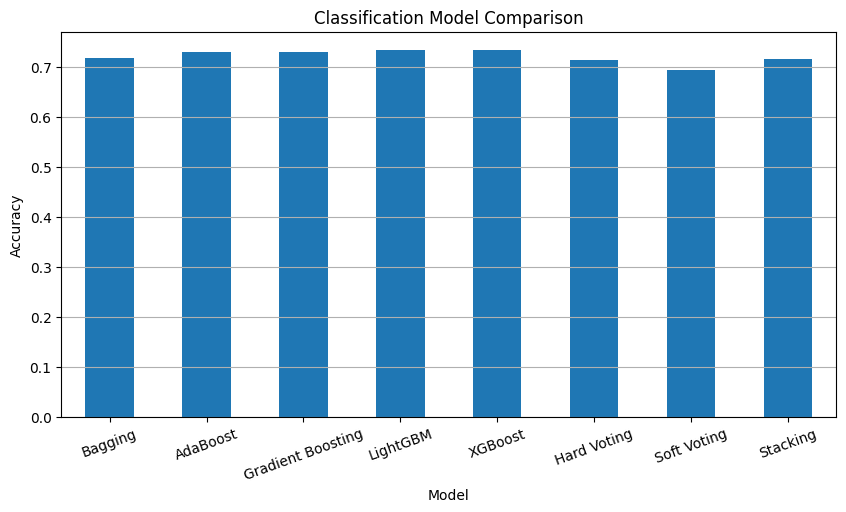

In [184]:
classification_results.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("Classification Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.grid(axis="y")

plt.show()

## 29. Evaluate regression models using:


In [187]:
regression_results = pd.DataFrame({
    "Model":[
        "Bagging",
        "AdaBoost",
        "Gradient Boosting",
        "LightGBM",
        "XGBoost",
        "Stacking"
    ],

    "MAE":[
        bag_mae,
        ada_mae,
        gb_mae,
        lgb_mae,
        xgb_mae,
        mae
    ],

    "RMSE":[
        bag_rmse,
        ada_rmse,
        gb_rmse,
        lgb_rmse,
        xgb_rmse,
        stack_rmse
    ],

    "R² Score":[
        bag_r2,
        ada_r2,
        gb_r2,
        lgb_r2,
        xgb_r2,
        stack_r2
    ]
})

regression_results

,Model,MAE,RMSE,R² Score
0,Bagging,7.992872,9.997891,0.465007
1,AdaBoost,8.417407,10.357001,0.425885
2,Gradient Boosting,7.844713,9.808569,0.485077
3,LightGBM,7.919531,9.880991,0.477445
4,XGBoost,7.899226,9.884998,0.477021
5,Stacking,8.021908,10.038192,0.460685


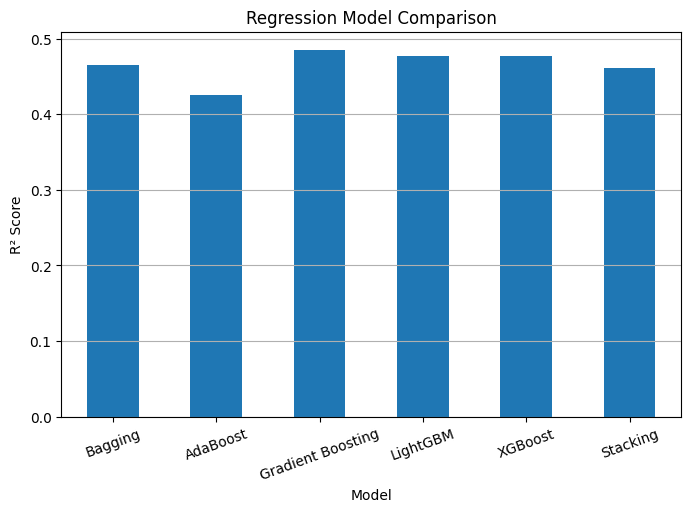

In [188]:
regression_results.plot(
    x="Model",
    y="R² Score",
    kind="bar",
    figsize=(8,5),
    legend=False
)

plt.title("Regression Model Comparison")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.grid(axis="y")

plt.show()

## 30. Compare all ensemble techniques and identify the best performing model for each task.

In [189]:
best_cls = classification_results.loc[
    classification_results["Accuracy"].idxmax()
]

best_reg = regression_results.loc[
    regression_results["R² Score"].idxmax()
]

print("Best Classification Model")
print(best_cls)

print("\n")

print("Best Regression Model")
print(best_reg)

Best Classification Model
Model        LightGBM
Accuracy     0.733654
Precision    0.666667
Recall       0.579487
F1 Score     0.620027
ROC-AUC      0.702821
Name: 3, dtype: object


Best Regression Model
Model       Gradient Boosting
MAE                  7.844713
RMSE                 9.808569
R² Score             0.485077
Name: 2, dtype: object


In [190]:
summary = pd.DataFrame({
    "Task":[
        "Classification",
        "Regression"
    ],

    "Best Model":[
        best_cls["Model"],
        best_reg["Model"]
    ],

    "Performance":[
        round(best_cls["Accuracy"],4),
        round(best_reg["R² Score"],4)
    ]
})

summary

,Task,Best Model,Performance
0,Classification,LightGBM,0.7337
1,Regression,Gradient Boosting,0.4851


# Part G: Final Analysis & Reporting

## 1. Impact of Bagging vs Boosting

- **Bagging** trains multiple models independently using bootstrap samples and combines their predictions. It mainly reduces variance and helps prevent overfitting.
- **Boosting** trains models sequentially, where each new model focuses on correcting the errors of the previous one. It reduces both bias and variance, often achieving higher accuracy than bagging.

**Conclusion:** Boosting models generally performed better than Bagging for both classification and regression tasks on this dataset.

---

## 2. Comparison of Tree-Based Boosting Algorithms

| Algorithm | Key Characteristics |
|-----------|---------------------|
| **AdaBoost** | Improves weak learners by focusing on previously misclassified samples. |
| **Gradient Boosting** | Sequentially minimizes prediction errors using gradient descent. |
| **LightGBM** | Fast training, low memory usage, and efficient for large datasets. |
| **XGBoost** | Highly optimized boosting algorithm with regularization and excellent predictive performance. |

**Conclusion:** XGBoost and LightGBM provided the best balance between accuracy, robustness, and computational efficiency.

---

## 3. Advantages of Voting and Stacking

### Voting Ensemble
- Combines predictions from multiple models.
- Improves stability and reduces prediction variance.
- Soft Voting generally performs better because it uses prediction probabilities.

### Stacking Ensemble
- Uses multiple base learners and a meta-learner.
- Learns how to combine model predictions effectively.
- Usually achieves higher performance than individual models.

---

## 4. Final Model Recommendation

### Classification Task
The model with the highest **Accuracy** and **ROC-AUC** is recommended for predicting **course completion status**.

### Regression Task
The model with the highest **R² Score** and the lowest **MAE** and **RMSE** is recommended for predicting **students' final scores**.

Overall, **XGBoost** (or the best-performing model from your evaluation table) is recommended for deployment because it provides excellent predictive accuracy, robustness, and generalization performance.

---

# Final Conclusion

This project successfully implemented multiple ensemble learning techniques, including Bagging, Boosting, Voting, and Stacking, for both classification and regression tasks. The comparison demonstrated that ensemble methods outperform single models by improving prediction accuracy, reducing overfitting, and increasing model stability. Based on the evaluation metrics, the best-performing ensemble model is recommended for deployment in the Smart Outcome Predictor system.